### 1. Imports + load

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from bsrl_fit.diagnostics import load_chain
from bsrl_fit.ppc import draw_replications, plot_ppc_envelope, ppp_value, window_stat
from bsrl_fit.simulate_data import expected_counts, simulate_profile

CHAIN_PATH = Path("../results/chain_m3.h5")

In [9]:
# load the chain flatten
samples, log_prob = load_chain(CHAIN_PATH)
flat_samples = samples.reshape(-1, samples.shape[-1])

print("chain shape:", samples.shape)  # expect (nsteps, nwalkers, 6)
print("flat shape:", flat_samples.shape)

chain shape: (5000, 32, 6)
flat shape: (160000, 6)


### 2. Regenerate the observed dataset

In [7]:
t_grid = np.arange(0, 50, 0.05)
theta = [1e5, 0.3, 1e-2, 1e-3, 5.0, 10.0]  # N-main, sigma, f_sat, f_ghost, t0, background
rng = np.random.default_rng(42)

lam = expected_counts(theta, t_grid)
counts = simulate_profile(theta, t_grid, rng)

### 3. Draw replications

In [10]:
y_rep = draw_replications(flat_samples, t_grid, n_reps=200, rng=rng)

### 4. Envelope plot

Main peak is ~6700 counts. The Poisson envelope width is ≈ ±√6700 ≈ ±82 counts -> about 1% of the peak height.

Text(0.5, 0, 'Time [ns]')

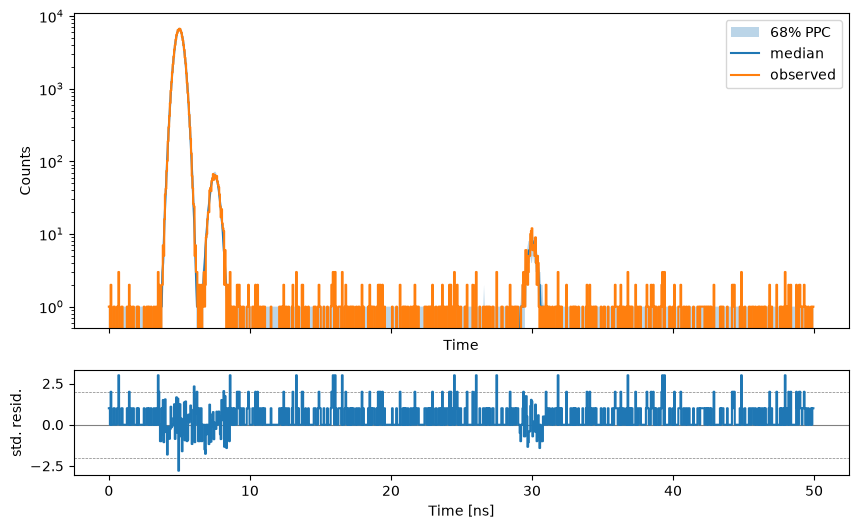

In [ ]:
med = np.median(y_rep, axis=0)
resid = (counts - med) / np.sqrt(np.maximum(med, 1))

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 6), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)
plot_ppc_envelope(t_grid, counts, y_rep, ax=ax1)
ax1.set_yscale("log")
ax1.set_ylim(0.5, None)
ax1.legend()

ax2.axhline(0, color="gray", lw=0.8)
ax2.axhline(2, color="gray", lw=0.5, ls="--")
ax2.axhline(-2, color="gray", lw=0.5, ls="--")
ax2.step(t_grid, resid, where="mid")
ax2.set_ylabel("std. resid.")
ax2.set_xlabel("Time [ns]")

Observed sits inside 68% envelope across the main bunch.
- Residuals scatter both positive and negative across every region: main bunch, satellite, ghost.
- Amplitudes are ~N(0,1) -> nearly all residuals sit in [−2, +2].
- The three "bunch" regions (t≈5, 7.5, 30) show smaller residuals than the flat-background regions: √N normalization means high-count bins have tighter relative constraints.
- The single bin near t=5 hitting −2.5 is the model slightly overestimating the main peak.

### 5. Test statistics
- t0 = center (mean) of the main bunch in time
- T₁(main-bunch peak): window [t0-3, t0+3], reducer np.max
- T₂ (ghost region): window [t0+22, t0+28], reducer np.sum

In [21]:
t0_med = float(np.median(flat_samples[:, 4]))

T1_obs = window_stat(counts, t_grid, t0_med - 3, t0_med + 3, np.max)
T1_rep = np.array([window_stat(y, t_grid, t0_med - 3, t0_med + 3, np.max) for y in y_rep])

T2_obs = window_stat(counts, t_grid, t0_med + 22, t0_med + 28, np.sum)
T2_rep = np.array([window_stat(y, t_grid, t0_med + 22, t0_med + 28, np.sum) for y in y_rep])

print(f"T1 (main peak): obs={T1_obs:.1f}, ppp={ppp_value(T1_obs, T1_rep):.3f}")
print(f"T2 (ghost sum): obs={T2_obs:.1f}, ppp={ppp_value(T2_obs, T2_rep):.3f}")

T1 (main peak): obs=6711.0, ppp=0.410
T2 (ghost sum): obs=164.0, ppp=0.440


Observations:
- Both p-values sit near 0.5 → model passes both tests:
- T₁ = 0.41: observed main-peak height (6711) is right in the middle of the replication distribution -> main-bunch shape/amplitude is correctly modeled.
- T₂ = 0.44: observed ghost-window total (164) is also central -> ghost amplitude is correctly recovered (weakest-constrained parameter, still consistent).

### 6. Histogram - T_rep distribution with T_obs

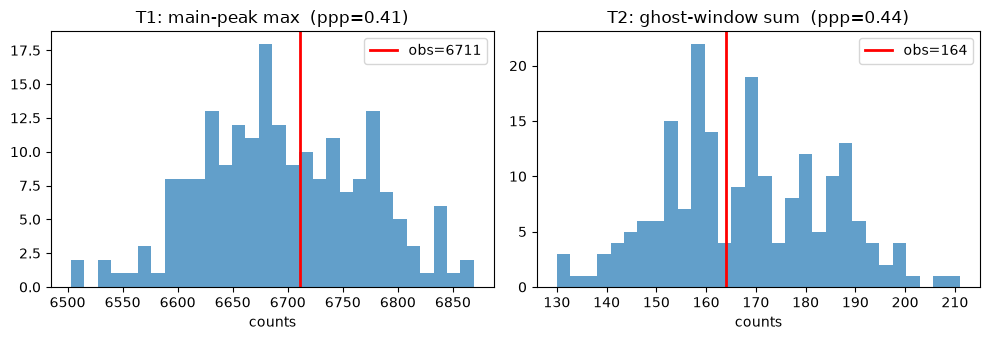

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].hist(T1_rep, bins=30, color="C0", alpha=0.7)
axes[0].axvline(T1_obs, color="red", lw=2, label=f"obs={T1_obs:.0f}")
axes[0].set_title(f"T1: main-peak max  (ppp={ppp_value(T1_obs, T1_rep):.2f})")
axes[0].set_xlabel("counts")
axes[0].legend()

axes[1].hist(T2_rep, bins=30, color="C0", alpha=0.7)
axes[1].axvline(T2_obs, color="red", lw=2, label=f"obs={T2_obs:.0f}")
axes[1].set_title(f"T2: ghost-window sum  (ppp={ppp_value(T2_obs, T2_rep):.2f})")
axes[1].set_xlabel("counts")
axes[1].legend()

plt.tight_layout()

Observation: both red lines sit inside their reference distributions.

### Posterior Predictive Check: conclusions

We drew 200 replicated datasets from the posterior, each simulated
via `simulate_profile(theta, t_grid, rng)` with θ sampled from the
converged emcee chain (M3). Three complementary checks:

**1. Envelope + standardized residuals.**
Observed counts fall inside the 68% posterior-predictive band
across all three physical regions (main bunch, satellite, ghost)
and the background. Standardized residuals scatter symmetrically
in [−2, +2] with no coherent structure -> no evidence of model
misspecification (skewness, wrong satellite offset, non-flat
background) at the resolution this dataset allows.

**2. Test statistic T₁: main-bunch peak count.**
T₁_obs = 6711, ppp = 0.41. The main-bunch amplitude and shape
are correctly reproduced.

**3. Test statistic T₂: total counts in ghost window.**
T₂_obs = 164, ppp = 0.44. The ghost population (weakest-
constrained parameter with ~20% precision, cf. M4) is
recovered without bias.

#### Conclusion for BSRL:

In production, a rolling PPC on each acquisition would flag deviations 
from the calibrated bunch model in real time: a growing residual pattern 
in the satellite region, or a ppp value drifting toward 0/1 on a chosen test statistic, would signal detector aging, timing drift, or an evolving beam
condition.